In [3]:
# Cell 1: Imports and Plotting Configuration
import sys
from pathlib import Path
from typing import Dict, List, Tuple

import numpy as np
import torch
import matplotlib.pyplot as plt
from sklearn.metrics import roc_curve, auc

# Ensure the src/ directory is in the Python path
sys.path.append(str(Path("..").resolve() / "src"))

from core.detector import FaceDetector
from core.embedder import VGGFaceEmbedder

# Configure matplotlib for IEEE academic paper standards
plt.rcParams.update({
    "font.family": "serif",
    "font.size": 11,
    "axes.grid": True,
    "grid.alpha": 0.5,
    "figure.figsize": (7, 5),
    "savefig.dpi": 300,
    "savefig.bbox": "tight"
})

# Define paths
EVAL_DIR = Path("../data/evaluation")
WEIGHTS_PATH = Path("../models/vgg_face_dag.pth")

In [4]:
# Cell 2: Extract Evaluation Embeddings
def extract_evaluation_features(eval_dir: Path, weights_path: Path) -> Tuple[torch.Tensor, np.ndarray]:
    """
    Extracts embeddings for all images in the evaluation directory.

    Args:
        eval_dir (Path): Directory containing evaluation .jpg images.
        weights_path (Path): Path to the VGGFace weights.

    Returns:
        Tuple[torch.Tensor, np.ndarray]: A tuple containing the (N, 4096) 
            tensor of embeddings and an (N,) numpy array of string labels.
    """
    detector = FaceDetector(image_size=224)
    embedder = VGGFaceEmbedder(weights_path=weights_path)
    
    embeddings_list: List[torch.Tensor] = []
    labels_list: List[str] = []
    
    image_paths = list(eval_dir.glob("*.jpg"))
    print(f"Found {len(image_paths)} evaluation images.")
    
    for img_path in image_paths:
        label = img_path.stem.split('_')[0]
        face_tensor = detector.process_frame(img_path)
        
        if face_tensor is not None:
            emb = embedder.get_embedding(face_tensor)
            embeddings_list.append(emb)
            labels_list.append(label)
            
    embeddings_matrix = torch.cat(embeddings_list, dim=0)
    labels_array = np.array(labels_list)
    
    print(f"Successfully extracted {embeddings_matrix.size(0)} embeddings.")
    return embeddings_matrix, labels_array

# Execute extraction
eval_embeddings, eval_labels = extract_evaluation_features(EVAL_DIR, WEIGHTS_PATH)

INFO: Initializing MTCNN FaceDetector on device: cuda:0
INFO: Initializing VGGFace on device: cuda:0
INFO: VGGFace Embedder initialized and classification head stripped.


Found 1169 evaluation images.
Successfully extracted 1016 embeddings.


In [5]:
# Cell 3: Pair Generation and Mathematical Evaluation
def compute_roc_metrics(
    embeddings: torch.Tensor, 
    labels: np.ndarray
) -> Tuple[np.ndarray, np.ndarray, np.ndarray, float, float]:
    """
    Computes pairwise similarities and extracts ROC metrics and the Equal Error Rate.

    Args:
        embeddings (torch.Tensor): (N, 4096) tensor of L2-normalized features.
        labels (np.ndarray): (N,) array of identity labels.

    Returns:
        Tuple containing FPR array, TPR array, thresholds array, ROC AUC, and EER.
    """
    # 1. Compute the N x N Similarity Matrix (Dot Product of normalized vectors)
    similarity_matrix = torch.mm(embeddings, embeddings.t()).numpy()
    
    # 2. Create the N x N Ground Truth Boolean Matrix
    # True if labels match (Genuine), False if they differ (Imposter)
    # Using broadcasting: labels[:, None] creates a column vector to compare against the row vector
    ground_truth_matrix = (labels[:, None] == labels[None, :])
    
    # 3. Extract the upper triangle indices to avoid self-pairs (diagonal) 
    # and duplicate reverse pairs (lower triangle)
    upper_tri_indices = np.triu_indices_from(similarity_matrix, k=1)
    
    scores = similarity_matrix[upper_tri_indices]
    y_true = ground_truth_matrix[upper_tri_indices].astype(int)
    
    genuine_count = np.sum(y_true == 1)
    imposter_count = np.sum(y_true == 0)
    print(f"Generated {genuine_count} Genuine Pairs and {imposter_count} Imposter Pairs.")
    
    # 4. Calculate ROC Curve parameters
    fpr, tpr, thresholds = roc_curve(y_true, scores)
    roc_auc = auc(fpr, tpr)
    
    # 5. Calculate Equal Error Rate (EER)
    # EER is mathematically the point where False Acceptance Rate (FPR) equals 
    # False Rejection Rate (1 - TPR)
    fnr = 1 - tpr
    eer_index = np.nanargmin(np.absolute(fnr - fpr))
    eer = fpr[eer_index]
    optimal_threshold = thresholds[eer_index]
    
    print(f"Optimal Threshold (tau) at EER: {optimal_threshold:.4f}")
    print(f"Equal Error Rate (EER): {eer:.4%}")
    
    return fpr, tpr, thresholds, roc_auc, optimal_threshold

# Execute evaluation
fpr, tpr, thresholds, roc_auc, tau = compute_roc_metrics(eval_embeddings, eval_labels)

Generated 153390 Genuine Pairs and 362230 Imposter Pairs.
Optimal Threshold (tau) at EER: 0.8453
Equal Error Rate (EER): 11.8414%


Saved ROC curve as 'roc_curve.pdf'


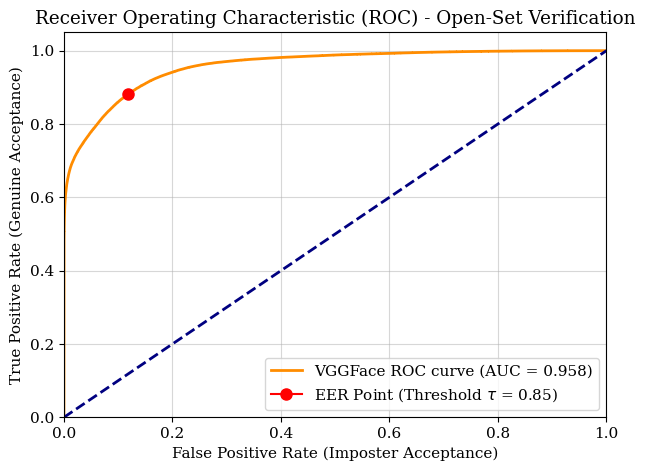

In [7]:
# Cell 4: Plotting and Exporting Figures
def plot_evaluation_results(fpr: np.ndarray, tpr: np.ndarray, roc_auc: float, eer_threshold: float):
    """
    Plots the ROC curve and saves it as a high-resolution PDF for Typst integration.
    """
    plt.figure()
    plt.plot(fpr, tpr, color='darkorange', lw=2, label=f'VGGFace ROC curve (AUC = {roc_auc:.3f})')
    
    # Plot the random guess baseline
    plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')
    
    # Highlight the EER point
    eer_index = np.nanargmin(np.absolute((1 - tpr) - fpr))
    plt.plot(fpr[eer_index], tpr[eer_index], marker='o', color='red', markersize=8, 
             label=f'EER Point (Threshold $\\tau$ = {eer_threshold:.2f})')
    
    plt.xlim([0.0, 1.0])
    plt.ylim([0.0, 1.05])
    plt.xlabel('False Positive Rate (Imposter Acceptance)')
    plt.ylabel('True Positive Rate (Genuine Acceptance)')
    plt.title('Receiver Operating Characteristic (ROC) - Open-Set Verification')
    plt.legend(loc="lower right")
    
    # Save as PDF for Typst
    plt.savefig("roc_curve.pdf")
    print("Saved ROC curve as 'roc_curve.pdf'")
    plt.show()

# Execute plotting
plot_evaluation_results(fpr, tpr, roc_auc, tau)